/usr/local/lib/python3.10/dist-packages/tensorflow/lite/python/util.py:55: DeprecationWarning: jax.xla_computation is deprecated. Please use the AOT APIs; see https://jax.readthedocs.io/en/latest/aot.html. For example, replace xla_computation(f)(*xs) with jit(f).lower(*xs).compiler_ir('hlo'). See CHANGELOG.md for 0.4.30 for more examples.
  from jax import xla_computation as _xla_computation
/usr/local/lib/python3.10/dist-packages/gymnasium/core.py:297: UserWarning: WARN: env.num_envs to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.num_envs` for environment variables or `env.get_attr('num_envs')` that will search the reminding wrappers.
  logger.warn(


Episode: 100000, Total Reward: -17699.00, Total Bet: 112071.00, Reward/Bet Ratio: -15.79%
Episode: 200000, Total Reward: -28415.50, Total Bet: 223543.00, Reward/Bet Ratio: -12.71%
Episode: 300000, Total Reward: -38498.50, Total Bet: 333145.00, Reward/Bet Ratio: -11.56%
Episode: 400000, Total Reward: -48791.00, Total Bet: 443807.00, Reward/Bet Ratio: -10.99%
Episode: 500000, Total Reward: -59082.00, Total Bet: 554174.00, Reward/Bet Ratio: -10.66%
Episode: 600000, Total Reward: -69073.00, Total Bet: 664897.00, Reward/Bet Ratio: -10.39%
Episode: 700000, Total Reward: -78831.50, Total Bet: 776115.00, Reward/Bet Ratio: -10.16%
Episode: 800000, Total Reward: -88576.00, Total Bet: 888268.00, Reward/Bet Ratio: -9.97%
Episode: 900000, Total Reward: -98358.50, Total Bet: 1000589.00, Reward/Bet Ratio: -9.83%
Episode: 1000000, Total Reward: -108077.00, Total Bet: 1113241.00, Reward/Bet Ratio: -9.71%
Episode: 1100000, Total Reward: -118267.00, Total Bet: 1225038.00, Reward/Bet Ratio: -9.65%
Episode

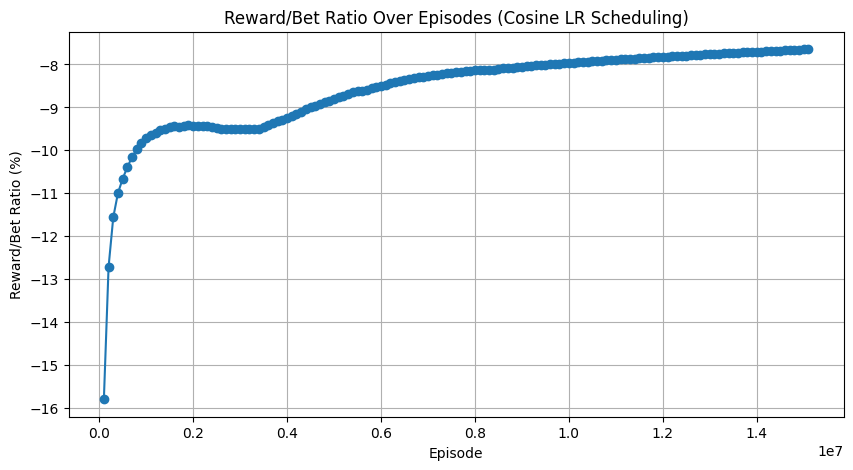

/usr/local/lib/python3.10/dist-packages/gymnasium/core.py:297: UserWarning: WARN: env.num_envs to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.num_envs` for environment variables or `env.get_attr('num_envs')` that will search the reminding wrappers.
  logger.warn(
/usr/local/lib/python3.10/dist-packages/stable_baselines3/common/save_util.py:437: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unl

Starting evaluation...
Episode 1000: Reward/Bet Ratio = -2.03%
Episode 2000: Reward/Bet Ratio = -4.02%
Episode 3000: Reward/Bet Ratio = -4.72%
Episode 4000: Reward/Bet Ratio = -6.43%
Episode 5000: Reward/Bet Ratio = -7.06%
Episode 6000: Reward/Bet Ratio = -6.97%
Episode 7000: Reward/Bet Ratio = -6.87%
Episode 8000: Reward/Bet Ratio = -6.79%
Episode 9000: Reward/Bet Ratio = -6.74%
Episode 10000: Reward/Bet Ratio = -6.79%
Episode 11000: Reward/Bet Ratio = -6.90%
Episode 12000: Reward/Bet Ratio = -7.02%
Episode 13000: Reward/Bet Ratio = -7.42%
Episode 14000: Reward/Bet Ratio = -7.49%
Episode 15000: Reward/Bet Ratio = -7.34%
Episode 16000: Reward/Bet Ratio = -7.24%
Episode 17000: Reward/Bet Ratio = -7.06%
Episode 18000: Reward/Bet Ratio = -7.16%
Episode 19000: Reward/Bet Ratio = -7.33%
Episode 20000: Reward/Bet Ratio = -7.38%
Episode 21000: Reward/Bet Ratio = -7.28%
Episode 22000: Reward/Bet Ratio = -7.16%
Episode 23000: Reward/Bet Ratio = -7.42%
Episode 24000: Reward/Bet Ratio = -7.54%
Ep

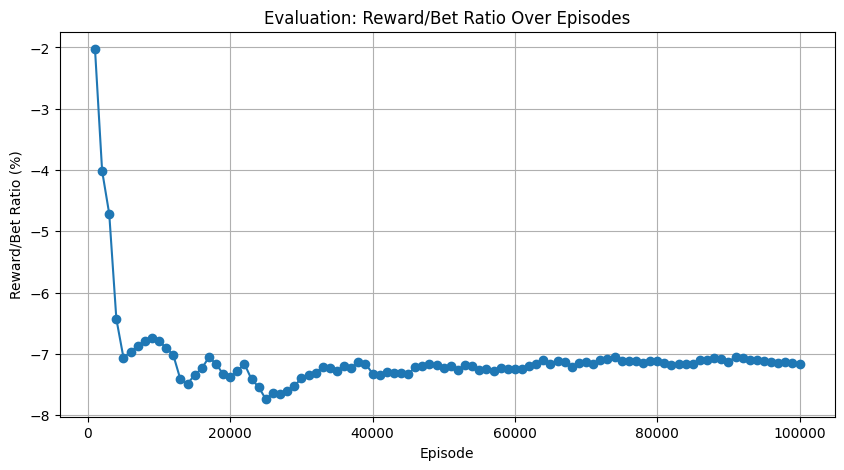

In [1]:
import gymnasium as gym
from gymnasium import spaces
import numpy as np
import random
import math
import matplotlib.pyplot as plt
from stable_baselines3 import PPO
from stable_baselines3.common.callbacks import BaseCallback
from stable_baselines3.common.env_checker import check_env
from gymnasium.wrappers import RecordEpisodeStatistics

class BlackjackEnvInfinite(gym.Env):
    """
    Custom Blackjack environment with an infinite deck.
    
    State (MultiDiscrete):
      [player_sum, dealer_card, usable_ace, first_move]
      
      - player_sum: Sum of player's hand (0 to 31)
      - dealer_card: Dealer's face-up card (1-10; note: 0 is unused)
      - usable_ace: 0 (False) or 1 (True)
      - first_move: 1 if it's the first decision, else 0
     
    Actions (Discrete(4)):
      0: HIT      – Request another card.
      1: STK      – Stand.
      2: DBL      – Double Down (only on first move).
      3: SUR      – Surrender (only on first move).
    """
    def __init__(self, payout_blackjack=1.5):
        super(BlackjackEnvInfinite, self).__init__()
        self.action_space = spaces.Discrete(4)
        # Use a flattened observation space instead of Tuple.
        self.observation_space = spaces.MultiDiscrete([32, 11, 2, 2])
        self.payout_blackjack = payout_blackjack
        self.base_bet = 1.0
        self.reset()
    
    def _draw_card(self):
        """Draw a card from an infinite deck with equal probability."""
        # Cards: Ace=1, cards 2-9, and four 10-value cards (10, J, Q, K)
        cards = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 10, 10, 10]
        return random.choice(cards)
    
    def _hand_value(self, hand):
        """Compute the hand's total and whether a usable ace is present."""
        total = sum(hand)
        usable_ace = 0
        # If an Ace is present and counting it as 11 doesn't bust, do so.
        if 1 in hand and total + 10 <= 21:
            total += 10
            usable_ace = 1
        return total, usable_ace
    
    def _get_observation(self):
        """Return the observation as a flattened numpy array."""
        player_total, usable = self._hand_value(self.player_hand)
        dealer_card = self.dealer_hand[0]
        first_move_val = 1 if self.first_move else 0
        return np.array([player_total, dealer_card, usable, first_move_val], dtype=np.int32)
    
    def reset(self, seed=None, options=None):
        """Reset the environment for a new round."""
        self.first_move = True
        self.done = False
        self.reward = 0.0
        
        # Deal two cards each to player and dealer.
        self.player_hand = [self._draw_card(), self._draw_card()]
        self.dealer_hand = [self._draw_card(), self._draw_card()]
        
        player_total, _ = self._hand_value(self.player_hand)
        dealer_total, _ = self._hand_value(self.dealer_hand)
        
        # Check for natural blackjack.
        if player_total == 21:
            if dealer_total == 21:
                self.done = True
                self.reward = 0.0
            else:
                self.done = True
                self.reward = self.payout_blackjack * self.base_bet
        return self._get_observation(), {}
    
    def step(self, action):
        """Take an action in the environment."""
        if self.done:
            return self._get_observation(), 0.0, True, False, {}
        
        # On moves after the first, only HIT (0) and STK (1) are allowed.
        if not self.first_move and action in [2, 3]:
            self.done = True
            return self._get_observation(), -1.0, True, False, {"illegal_action": True}
        
        if action == 0:  # HIT
            card = self._draw_card()
            self.player_hand.append(card)
            player_total, _ = self._hand_value(self.player_hand)
            if player_total > 21:
                self.done = True
                reward = -self.base_bet
            else:
                reward = 0.0
            self.first_move = False
            return self._get_observation(), reward, self.done, False, {}
        
        elif action == 1:  # STAND
            reward = self._dealer_play()
            self.done = True
            return self._get_observation(), reward, self.done, False, {}
        
        elif action == 2:  # DOUBLE DOWN
            self.first_move = False
            card = self._draw_card()
            self.player_hand.append(card)
            player_total, _ = self._hand_value(self.player_hand)
            if player_total > 21:
                reward = -2 * self.base_bet
                self.done = True
                return self._get_observation(), reward, self.done, False, {}
            reward = self._dealer_play(double_down=True)
            self.done = True
            return self._get_observation(), reward, self.done, False, {}
        
        elif action == 3:  # SURRENDER
            self.first_move = False
            self.done = True
            reward = -0.5 * self.base_bet
            return self._get_observation(), reward, self.done, False, {}
        
        else:
            self.done = True
            return self._get_observation(), -1.0, True, False, {"illegal_action": True}
    
    def _dealer_play(self, double_down=False):
        """Simulate the dealer's play and determine the outcome."""
        player_total, _ = self._hand_value(self.player_hand)
        dealer_total, _ = self._hand_value(self.dealer_hand)
        
        # Dealer draws until reaching 17 or more.
        while dealer_total < 17:
            self.dealer_hand.append(self._draw_card())
            dealer_total, _ = self._hand_value(self.dealer_hand)
        
        bet = self.base_bet * (2 if double_down else 1)
        if dealer_total > 21:
            return bet
        elif dealer_total > player_total:
            return -bet
        elif dealer_total < player_total:
            return bet
        else:
            return 0.0
    
    def render(self, mode='human'):
        """Print a simple representation of the current state."""
        player_total, usable = self._hand_value(self.player_hand)
        dealer_total, _ = self._hand_value(self.dealer_hand)
        print(f"Player hand: {self.player_hand} (Total: {player_total}, Usable Ace: {usable})")
        print(f"Dealer hand: {self.dealer_hand} (Total: {dealer_total})")

# ----------------------------
# Custom Wrapper to Attach Bet Info
# ----------------------------
class BetInfoWrapper(gym.Wrapper):
    """
    A gym Wrapper that records the bet placed in an episode.
    If the final action was DOUBLE DOWN, the bet is 2.0; otherwise, it is 1.0.
    """
    def __init__(self, env):
        super(BetInfoWrapper, self).__init__(env)
    
    def step(self, action):
        self.last_action = action
        obs, reward, terminated, truncated, info = self.env.step(action)
        if terminated or truncated:
            info["bet"] = 2.0 if self.last_action == 2 else 1.0
        return obs, reward, terminated, truncated, info

# ----------------------------
# Custom Callback for Training Metrics
# ----------------------------
class TrainingMetricsCallback(BaseCallback):
    """
    Custom callback that logs and stores the reward-to-bet ratio every 'print_freq' episodes.
    """
    def __init__(self, print_freq=100_000, verbose=0):
        super(TrainingMetricsCallback, self).__init__(verbose)
        self.print_freq = print_freq
        self.total_reward = 0.0
        self.total_bet = 0.0
        self.episode_count = 0
        self.episode_history = []
        self.ratio_history = []
    
    def _on_step(self) -> bool:
        infos = self.locals.get("infos", None)
        if infos is not None:
            if isinstance(infos, list):
                for info in infos:
                    if "episode" in info:
                        self.episode_count += 1
                        self.total_reward += info["episode"]["r"]
                        self.total_bet += info.get("bet", 1.0)
                        if self.episode_count % self.print_freq == 0:
                            ratio = (self.total_reward / self.total_bet * 100.0) if self.total_bet > 0 else 0.0
                            print(f"Episode: {self.episode_count}, Total Reward: {self.total_reward:.2f}, "
                                  f"Total Bet: {self.total_bet:.2f}, Reward/Bet Ratio: {ratio:.2f}%")
                            self.episode_history.append(self.episode_count)
                            self.ratio_history.append(ratio)
            else:
                if "episode" in infos:
                    self.episode_count += 1
                    self.total_reward += infos["episode"]["r"]
                    self.total_bet += infos.get("bet", 1.0)
                    if self.episode_count % self.print_freq == 0:
                        ratio = (self.total_reward / self.total_bet * 100.0) if self.total_bet > 0 else 0.0
                        print(f"Episode: {self.episode_count}, Total Reward: {self.total_reward:.2f}, "
                              f"Total Bet: {self.total_bet:.2f}, Reward/Bet Ratio: {ratio:.2f}%")
                        self.episode_history.append(self.episode_count)
                        self.ratio_history.append(ratio)
        return True

# ----------------------------
# Create the Environment and Wrap It
# ----------------------------
env = BlackjackEnvInfinite()
env = BetInfoWrapper(env)
env = RecordEpisodeStatistics(env)  # This wrapper records episode info under "episode"
check_env(env, warn=True)

# ----------------------------
# Define a Cosine Learning Rate Schedule
# ----------------------------
def cosine_lr_schedule(progress_remaining):
    lr_initial = 1e-4
    lr_min = 1e-6
    cosine_decay = 0.5 * (1 + math.cos(math.pi * (1 - progress_remaining)))
    return lr_min + (lr_initial - lr_min) * cosine_decay

# ----------------------------
# Initialize the PPO Agent
# ----------------------------
model = PPO(
    "MlpPolicy",
    env,
    gamma=0.99,
    learning_rate=cosine_lr_schedule,  # Cosine learning rate schedule
    verbose=0,
    n_steps=2048,
    batch_size=64,
    ent_coef=0.01,
)

metrics_callback = TrainingMetricsCallback(print_freq=100_000, verbose=0)

# ----------------------------
# Train the Model
# ----------------------------
model.learn(total_timesteps=20_000_000, callback=metrics_callback)
model.save("ppo_blackjack_infinite_model_cosine_lr")
print("Model training complete and saved as 'ppo_blackjack_infinite_model_cosine_lr'.")

# ----------------------------
# Plot the Reward/Bet Ratio Over Episodes (Training)
# ----------------------------
plt.figure(figsize=(10, 5))
plt.plot(metrics_callback.episode_history, metrics_callback.ratio_history, marker='o', linestyle='-')
plt.title("Reward/Bet Ratio Over Episodes (Cosine LR Scheduling)")
plt.xlabel("Episode")
plt.ylabel("Reward/Bet Ratio (%)")
plt.grid(True)
plt.show()

# ----------------------------
# Evaluation
# ----------------------------
eval_env = BlackjackEnvInfinite()
eval_env = BetInfoWrapper(eval_env)
eval_env = RecordEpisodeStatistics(eval_env)

# Load the trained model
model = PPO.load("ppo_blackjack_infinite_model_cosine_lr", env=eval_env)

num_episodes = 100_000
reward_history = []
bet_history = []
ratio_history_eval = []
episode_x = []

wins = 0
draws = 0
losses = 0

print("Starting evaluation...")
for episode in range(1, num_episodes + 1):
    obs, _ = eval_env.reset()
    done = False
    
    while not done:
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, done, truncated, info = eval_env.step(action)
    
    episode_reward = reward
    episode_bet = info.get("bet", 1.0)
    
    reward_history.append(episode_reward)
    bet_history.append(episode_bet)
    
    if episode_reward > 0:
        wins += 1
    elif episode_reward == 0:
        draws += 1
    else:
        losses += 1
    
    if episode % 1000 == 0:
        total_reward = np.sum(reward_history)
        total_bet = np.sum(bet_history)
        ratio = (total_reward / total_bet * 100) if total_bet > 0 else 0.0
        ratio_history_eval.append(ratio)
        episode_x.append(episode)
        print(f"Episode {episode}: Reward/Bet Ratio = {ratio:.2f}%")

win_percent = wins / num_episodes * 100
draw_percent = draws / num_episodes * 100
loss_percent = losses / num_episodes * 100

print("\nFinal Evaluation Results:")
print(f"Win %: {win_percent:.2f}%")
print(f"Draw %: {draw_percent:.2f}%")
print(f"Loss %: {loss_percent:.2f}%")

plt.figure(figsize=(10, 5))
plt.plot(episode_x, ratio_history_eval, marker='o', linestyle='-')
plt.title("Evaluation: Reward/Bet Ratio Over Episodes")
plt.xlabel("Episode")
plt.ylabel("Reward/Bet Ratio (%)")
plt.grid(True)
plt.show()